<a href="https://colab.research.google.com/github/Esteban-sb/telecom-analysis/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

In [ ]:
#importing libraries
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Loading Files
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# Exploring Dataset
plans.describe()

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
std,282.842712,10.606602,353.553391,9.192388,0.141421,0.021213,0.021213
min,100.000000,5.000000,100.000000,12.000000,1.000000,0.050000,0.070000
25%,200.000000,8.750000,225.000000,15.250000,1.050000,0.057500,0.077500
50%,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
75%,400.000000,16.250000,475.000000,21.750000,1.150000,0.072500,0.092500
max,500.000000,20.000000,600.000000,25.000000,1.200000,0.080000,0.100000


In [ ]:
# Exploring Dataset
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# Exploring Dataset
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [ ]:
# Reviewing rows and columns
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# Reviewing types of data
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Reviewing types of data
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# Reviewing types of data
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [ ]:
# Count of nulls for 'users'
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# Count of nulls for 'usage'
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

En 'users' las columnas 'city' (469) y churn_date (3534) cuentan con valores faltantes. En 'usage' las columnas date (50), duration (22076) y lenght (17896) cuentan con valores faltantes.
- Indica qué harías: ¿imputar, eliminar, ignorar?

En 'users' los valores faltantes de la columna 'city' seran investigados para eliminar o imputar, la columna 'churn_date' sera ignorada. En 'usage' la columna date sera investigada para eliminar y las columnas 'duration' y 'lenght' (dependiendo de su requerimiento) seran investigadas para imputacion o eliminacion.

In [ ]:
# Searching for invalid values or sentinels
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` cuenta con 4000 registros al igual que la columna "age"
- La columna `age` cuenta con el mismo numero de columnas que la columna "user_id", cuenta con valores atipicos ya que su menor registro es de -999.

In [ ]:
# Searching for invalid values or sentinels
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran valores comunes con 4000 registros
- Las columnas 'duration' y 'lenght' son valores que varian segun el usuario (ademas son mediciones de uso)

In [ ]:
# Exploring categoric columns of 'users'
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print(users[col].value_counts())


--- city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` cuenta con 6 registros unicos (o ciudades) pero ademas cuenta con 96 registros nulos
- La columna `plan` cuenta con dos valores unicos los cuales son 'Premium' y 'Basico', no cuenta con valores nulos

In [ ]:
# Exploring categoric columns of 'usage'
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` cuenta con dos valores unicos 'text' y 'call', no se encuentran valores faltantes

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En la columna 'age' se encuentran valores atipicos, siendo -999 el menor valor que se puede encontrar, ademas la columna 'city' cuenta con valores faltantes
- ¿Qué acción tomarías?

Para el caso de la columna 'age' los registros que muestren valores atipicios seran eliminados e imputados con la media y para la columna 'city' dependiendo del requerimiento, los valores seran ignorados o eliminados

In [ ]:
# Changing to date the column 'reg_date' of users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Changing to date the column 'date' of usersusage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Reviewing years in the column 'reg_date' of users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

In [ ]:
# Reviewing years in the column 'date' of usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

- En `reg_date` se encuentran registros desde el año 2022 hasta el año 2026
- En `date` se encuentran solo registros del año 2024  

Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?

En users, se encuentran valores para el año 2026, lo cual es imposible ya que los registros estan hasta el año 2024
- ¿Qué harías con ellas?

Si los registros no son requeridos para el analisis serian eliminados, de lo contrario serian imputados con la media

In [ ]:
# Replacing -999 for the median of the column 'age'
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verifying changes
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Replacing ? for NA of the column 'city'
users['city'] = users['city'].replace('?', pd.NA)

# Verifying changes
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marking future dates with NA for the column 'reg_date'
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verifying changes
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

In [ ]:
# Verifying MAR in 'usage' (Missing At Random) for 'duration'
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verifying MAR in 'usage' (Missing At Random) for 'length'
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

En `duration` y `length` los valores faltantes en ambas columnas son MAR. En 'length' por que el tipo 'text' no mide duracion de mensajes de texto y en 'duration' por que el tipo 'call' no mide el uso de datos (internet) en llamadas.

In [ ]:
# Auxiliary columns
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Grouping data by user
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# Result
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renaming columns
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# Result
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combining aggregated table with datase 'users'
user_profile = pd.merge(users, usage_agg, on = ['user_id', 'user_id'], how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


In [ ]:
# Statiscal summary of numerical columns
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               3999 non-null   int64         
 1   first_name            3999 non-null   object        
 2   last_name             3999 non-null   object        
 3   age                   3999 non-null   float64       
 4   city                  3434 non-null   object        
 5   reg_date              3959 non-null   datetime64[ns]
 6   plan                  3999 non-null   object        
 7   churn_date            466 non-null    object        
 8   cant_mensajes         3999 non-null   int64         
 9   cant_llamadas         3999 non-null   int64         
 10  cant_minutos_llamada  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 374.9+ KB


In [ ]:
# Percentil distribution of type of plans
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.87
Premium    35.13
Name: plan, dtype: float64

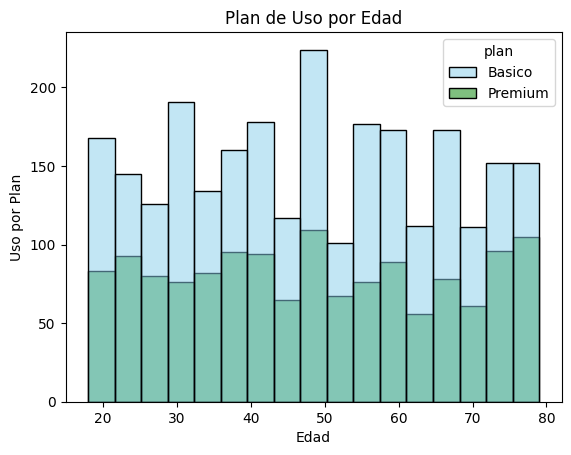

In [ ]:
# Histogram of 'age'
sb.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.ylabel('Uso por Plan')
plt.xlabel('Edad')
plt.title('Plan de Uso por Edad')
plt.show()

💡Insights:
- El plan basico es el mas usado entre la mayoria de edades, las personas con edades cerca a los 50 años tienden a preferir (o usar) el plan basico. El plan premium es el menos usado, siendo las edades entre 70 y 80 años las que mas lo utilizan.

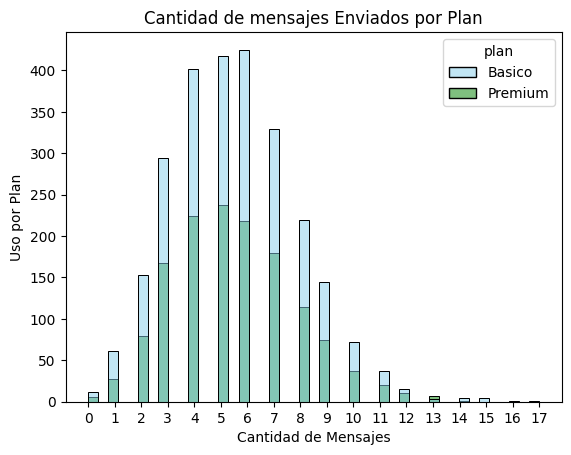

In [ ]:
# Histogram of 'cant_mensajes'
sb.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.xticks(range(0, int(user_profile['cant_mensajes'].max()) + 1))
plt.ylabel('Uso por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.title('Cantidad de mensajes Enviados por Plan')
plt.show()

💡Insights:
- Las personas que usan el plan premium envian un promedio de entre 3 y 7 mensajes, sin embargo, el plan basico es el mas utilizado para enviar mensajes, en promedio de 2 a 9 mensajes (de igual manera es el mas utilizado para enviar la mayor cantidad de mensajes 14/15).

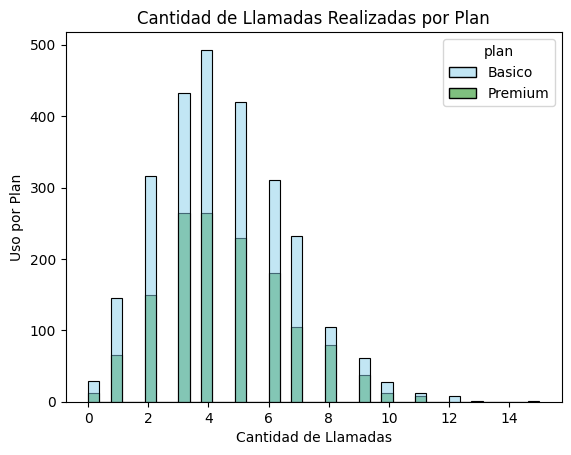

In [ ]:
# Histogram of 'cant_llamadas'
sb.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.ylabel('Uso por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.title('Cantidad de Llamadas Realizadas por Plan')
plt.show()

💡Insights:
- Las personas que usan el plan premium tienden a hacer de entre 3 a 4 llamadas, a diferencia de el plan basico, que las personas que lo prefieren tienden a hacer entre 2 y 7 llamadas.

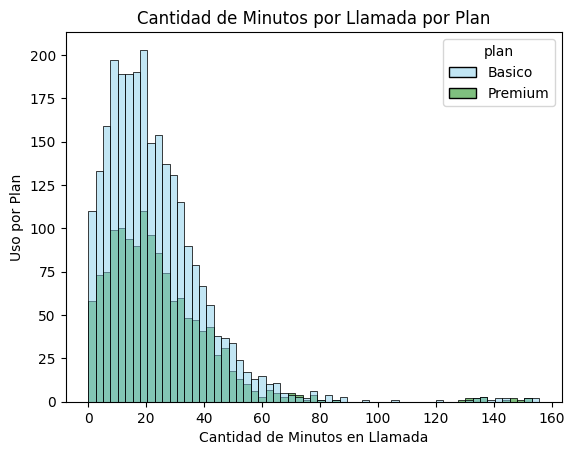

In [ ]:
# Histogram of 'cant_minutos_llamada'
sb.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.ylabel('Uso por Plan')
plt.xlabel('Cantidad de Minutos en Llamada')
plt.title('Cantidad de Minutos por Llamada por Plan')
plt.show()


💡Insights:
- El plan basico es el mas usado en duracion al momento de realizar llamadas, las personas que optaron por este plan suelen durar en llamada entre 1 a 30 minutos, pero ademas es el mas usado para llamadas de mas de 100 minutos. Las personas que optaron por el plan premium tienden a durar menos en llamadas siendo su mas alto duracion 20 minutos.

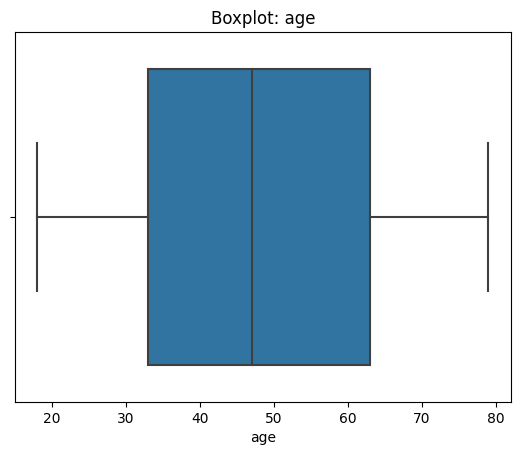

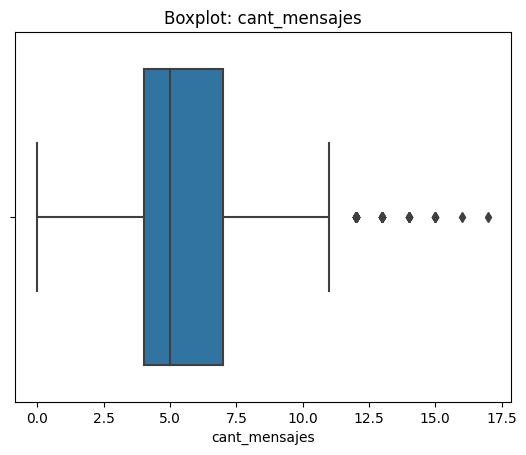

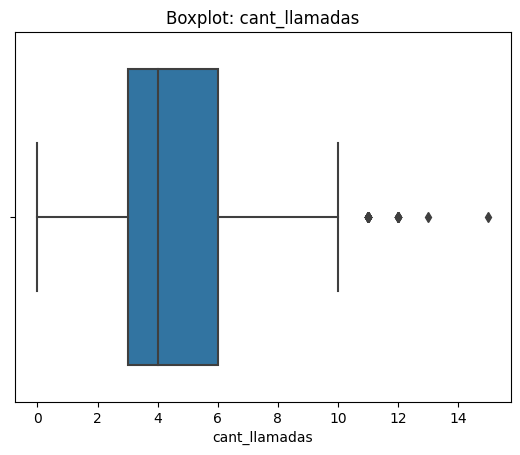

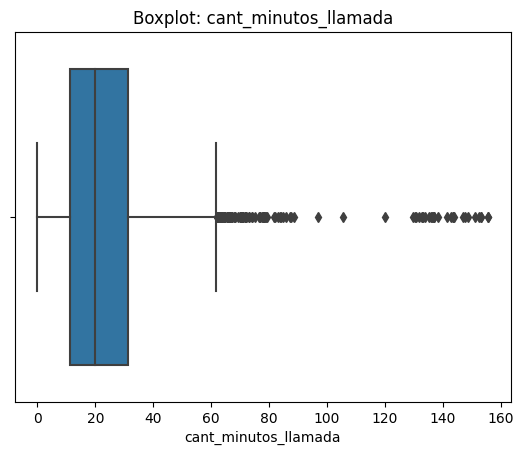

In [ ]:
# Viualizing numeric columns using boxPlots
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sb.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No contiene outliers
- cant_mensajes: Cuenta con la segunda canridad mas alta de outliers hacia la derecha
- cant_llamadas: Cuenta con la menor cantidad de outliers hacia la derecha
- cant_minutos_llamada: Cuenta con la mayor cantidad de outliers hacia la derecha

In [ ]:
# Calculating limits for IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for colm in columnas_limites:
    lower = user_profile[colm].quantile(0.25)
    upper = user_profile[colm].quantile(0.75)
    IQR = upper - lower
    a = upper + 1.5 * IQR
    b = lower - 1.5 * IQR
    col_name = colm + '_win'
    user_profile[col_name] = np.clip(user_profile[colm], lower, upper)

In [ ]:
# Reviewing limits and maximum values to determine how to handle outliers
Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?

Se mantendran ya que su desviacion y cantidad de datos no es alta
- cant_llamadas: mantener o no outliers, porqué?

Se mantendran ya que su desviacion y cantidad de datos no es alta
- cant_minutos_llamada: mantener o no outliers, porqué?

No se mantendran los datos (seran capados) siendo que presenta con la mayor cantidad de outliers

In [ ]:
# Creating a new column 'grupo_uso'
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
    np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))

In [ ]:
# Verifying changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,age_win,cant_mensajes_win,cant_llamadas_win,cant_minutos_llamada_win,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,38.0,7,3,23.700,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,53.0,5,6,31.415,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,57.0,5,3,11.120,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,63.0,7,3,11.120,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,63.0,4,3,11.120,Bajo uso


In [ ]:
# Creating a new column 'grupo_edad'
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30), 'Joven', np.where((user_profile['age'] < 60), 'Adulto', 'Adulto Mayor'))

In [ ]:
# Verifying changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,age_win,cant_mensajes_win,cant_llamadas_win,cant_minutos_llamada_win,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,38.0,7,3,23.700,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,53.0,5,6,31.415,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,57.0,5,3,11.120,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,63.0,7,3,11.120,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,63.0,4,3,11.120,Bajo uso,Adulto Mayor


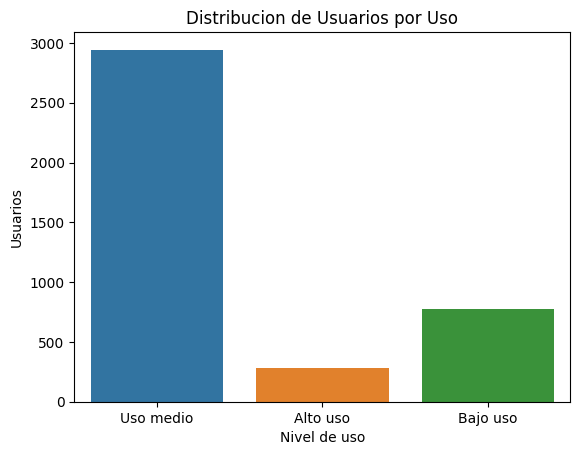

In [ ]:
# Visualizing user segments by usage
sb.countplot(data=user_profile, x= user_profile['grupo_uso'])
plt.title('Distribucion de Usuarios por Uso')
plt.xlabel('Nivel de uso')
plt.ylabel('Usuarios')
plt.show()

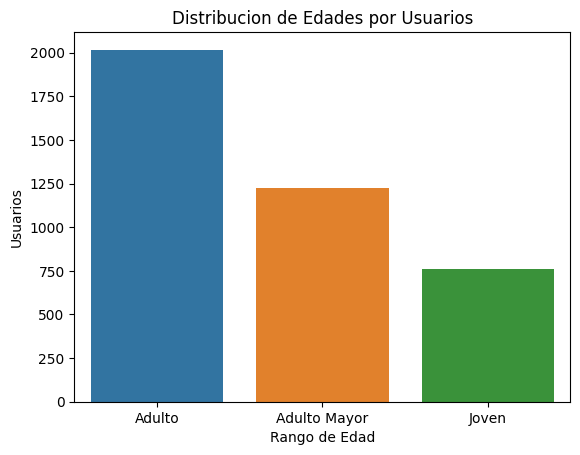

In [ ]:
# Visualizing user segments by age
sb.countplot(data=user_profile, x= user_profile['grupo_edad'])
plt.title('Distribucion de Usuarios por Edades')
plt.xlabel('Rango de Edad')
plt.ylabel('Usuarios')
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? - Originalmente los datos contaban con numerosos datos faltantes (nulos), ademas de presentar datos erroneos o mal ingresados (outliers).

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso? - La segmentacion de clientes se distribuye en rango de edades y nivel de uso. El rango de edad predominante en base a cantidad de usuarios es "Adulto" con 2017 usuarios, le sigue "Adulto Mayor" con 1222 usuarios y por ultimo "Joven" con 760 usuarios; Por otro lado en el rango de nivel de uso predomina "Uso Medio" con 2943 usuarios, le sige "Bajo Uso" con 778 usuarios y por ultimo "Alto Uso" con 278 usuarios.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? - Los segmentos "Adulto" y "Uso Medio" son los mas valiosos debido a que la mayoria de usuarios se concentran en los mismos.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? - En la columna 'age' se encontraron usuarios con edades de -999; en la columna 'city' no se encontraron datos registrados para algunas filas; en la columna 'date' se encontraron fechas para el año 2026 (Lo cual era imposible ya que los datos iban hasta 2024); en las columnas 'cant_mensaje', 'cant_llamadas' y 'duration' se encontraron valores extremos que podrian ser valores reales pero para casos especificos (como por ejemplo un usuario que ha realizado 17 llamadas o enviado 15 mensajes o haber durado en llamada por mas de una hora; Casos que podrian ser especificos a usuarios de uso recurrente)

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados? - Recomendaria una campaña de beneficios para los usuarios de "Uso Medio" siendo que son la mayoria de usuarios (sin importar su rango de edad); Beneficios como mas mensajes y mas minutos en llamada como obsequio (con finalidad de retener), descuentos y premios por usar recurrentemente el servicio. Una campaña publicitaria para atraer mas usuarios jovenes y adultos mayores.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores ausentes (registros de ciudades)
- Valores irreales (edades de -999 y fechas para el año 2026)

🔍 **Segmentos por Edad**
- Adulto Mayor (1222)
- Adulto (2017)
- Joven (760)

📊 **Segmentos por Nivel de Uso**
- Uso Alto (278)
- Uso Medio (2943)
- Uso Bajo (778)

➡️ Esto sugiere que la mayoria de usuarios se concentran en "adulto" y que ademas la mayoria mantiene un nivel de uso medio.

💡 **Recomendaciones**
- Beneficiar usuarios con nivel de "uso medio" con el fin de reternerlos.
- Generar campañas publicitarias para atraer mas usuarios jovenes.
- Premiar la fidelidad de los usuarios de "uso alto" con mas minutos en llamada o mensajes.